In [ ]:
# Cell 1: imports and file path

import zipfile
import pandas as pd
import numpy as np
from io import StringIO
from pathlib import Path
from uncertainties import ufloat
from uncertainties import unumpy as unp

# Locate the theorist constants zip locally (was hardcoded to another machine's path).
def _find_zip(name="SI_HFS_IS.zip"):
    for cand in (Path(name), Path(".") / name):
        if cand.exists():
            return str(cand)
    hits = list(Path(".").rglob(name))
    if hits:
        return str(hits[0])
    raise FileNotFoundError(f"{name} not found under the repo; place it in CREMA-Analysis/.")

zip_path = _find_zip("SI_HFS_IS.zip")
txt_member = "SI_HFS_IS/SI_HFS_IS.txt"
print("Using constants zip:", zip_path)


In [44]:
# Cell 2: read the theorist text file out of the zip

with zipfile.ZipFile(zip_path, "r") as zf:
    txt = zf.read(txt_member).decode("utf-8", errors="ignore")

lines = txt.splitlines()

for i, line in enumerate(lines[:25]):
    print(f"{i:3d}: {line}")


  0: --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  1:                                                                                            |               hyperfine constant        |   Normal mass shift |  Specific mass shift|                   |                               Field shift electronic factors
  2:  No        Configuration    Term  J Parity  Pos   Energy Total    Levels       E(NIST-ASD) |           A                   B         |    <K^1+K^2+K^3>    |   <K^1+K^2+K^3>     |  Electron density |         F0                 F2                  F4                   F6               F0VED0             F0VED1           
  3:                                                     (a.u.)        (cm^-1)        (cm

In [45]:
# Cell 3: parse the table rows into a dataframe
# Robust against the "|" separators in the GRASP summary table.

rows = []

for line in lines:
    stripped = line.strip()

    if not stripped:
        continue
    if not stripped[0].isdigit():
        continue

    # Split and remove the visual table separators
    parts = [p for p in stripped.split() if p != "|"]

    try:
        no = int(parts[0])
        config = parts[1]
        term = parts[2]
        J = int(parts[3])
        parity = parts[4]
        pos = int(parts[5])

        energy_total_au = float(parts[6])
        energy_cm1 = float(parts[7])
        nist_cm1 = float(parts[8]) if parts[8] != "-" else np.nan

        A_MHz = float(parts[9]) if parts[9] != "-" else np.nan
        B_MHz = float(parts[10]) if parts[10] != "-" else np.nan

        K_nms = float(parts[11])
        K_sms = float(parts[12])
        electron_density = float(parts[13])

        F0 = float(parts[14])
        F2 = float(parts[15])
        F4 = float(parts[16])
        F6 = float(parts[17])
        F0VED0 = float(parts[18])
        F0VED1 = float(parts[19])

        rows.append({
            "No": no,
            "Configuration": config,
            "Term": term,
            "J": J,
            "Parity": parity,
            "Pos": pos,
            "Energy_total_au": energy_total_au,
            "Energy_cm1": energy_cm1,
            "E_NIST_cm1": nist_cm1,
            "A_MHz": A_MHz,
            "B_MHz": B_MHz,
            "K_nms_GHz_u": K_nms,
            "K_sms_GHz_u": K_sms,
            "electron_density": electron_density,
            "F0_GHz_fm2": F0,
            "F2_GHz_fm4": F2,
            "F4_GHz_fm6": F4,
            "F6_GHz_fm8": F6,
            "F0VED0_GHz_fm2": F0VED0,
            "F0VED1_GHz_fm4": F0VED1,
            "raw_line": line,
        })
    except Exception as exc:
        print(f"Could not parse line:\n{line}\nError: {exc}\n")

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} rows")
df.head(10)

Could not parse line:
 94    3s(2).3p(3)4S3.7p     5P   1   +     13   -398.2793476    79593.27                  |    1.2385363317E+02    1.7012111397E-01 |  0.1433607335E+07   |   -0.2393295746E+06 |  0.2940941372E+04 |  0.2315622329E+03   -0.3793627823E-01   0.2928636846E-03   -0.1548335003E-05   0.2307094617E+03   -0.3197801238E-01  
Error: list index out of range

Could not parse line:
 95    3s(2).3p(3)4S3.7p     5P   2   +     16   -398.2793435    79594.18                  |    7.0380586008E+01   -2.0959512739E+00 |  0.1433607331E+07   |   -0.2393295726E+06 |  0.2940941357E+04 |  0.2315622318E+03   -0.3793627011E-01   0.2928633080E-03   -0.1548328900E-05   0.2307094606E+03   -0.3197800946E-01 
Error: list index out of range

Parsed 105 rows


,No,Configuration,Term,J,Parity,Pos,Energy_total_au,Energy_cm1,E_NIST_cm1,A_MHz,...,K_nms_GHz_u,K_sms_GHz_u,electron_density,F0_GHz_fm2,F2_GHz_fm4,F4_GHz_fm6,F6_GHz_fm8,F0VED0_GHz_fm2,F0VED1_GHz_fm4,raw_line
0,1,3s(2).3p(4)3P2,3P,2,+,1,-398.642001,0.00,0.0000,323.643763,...,1434697.266,-240084.5759,2939.366797,231.438255,-0.037927,0.000293,-0.000002,230.585827,-0.031965,1 3s(2).3p(4)3P2 3P 2 + 1...
1,2,3s(2).3p(4)3P2,3P,1,+,1,-398.640229,389.03,396.0565,26.402856,...,1434694.520,-240087.0174,2939.365189,231.438128,-0.037927,0.000293,-0.000002,230.585698,-0.031965,2 3s(2).3p(4)3P2 3P 1 + 1...
2,3,3s(2).3p(4)3P2,3P,0,+,1,-398.639430,564.28,573.5957,NaN,...,1434693.326,-240088.0634,2939.364519,231.438076,-0.037927,0.000293,-0.000002,230.585645,-0.031965,3 3s(2).3p(4)3P2 3P 0 + 1...
3,4,3s(2).3p(4)1D2,1D,2,+,2,-398.599201,9393.57,9238.6090,491.453700,...,1434579.477,-240035.3140,2939.434817,231.443611,-0.037927,0.000293,-0.000002,230.591164,-0.031965,4 3s(2).3p(4)1D2 1D 2 + 2...
4,5,3s(2).3p(4)1S0,1S,0,+,2,-398.538354,22747.88,22179.9542,NaN,...,1434400.523,-240087.2623,2939.160594,231.422019,-0.037922,0.000293,-0.000002,230.569668,-0.031962,5 3s(2).3p(4)1S0 1S 0 + 2...
5,6,3s(2).3p(3)4S3.4s,5S,2,-,1,-398.404145,52203.47,52623.6050,248.407246,...,1433980.481,-239342.0313,2941.544329,231.609708,-0.037965,0.000294,-0.000002,230.756537,-0.031992,6 3s(2).3p(3)4S3.4s 5S 2 - 1...
6,7,3s(2).3p(3)4S3.4s,3S,1,-,1,-398.391505,54977.63,55330.7750,51.756298,...,1433919.384,-239001.0637,2941.337494,231.593423,-0.037965,0.000294,-0.000002,230.740283,-0.031991,7 3s(2).3p(3)4S3.4s 3S 1 - 1...
7,8,3s(2).3p(3)4S3.4p,5P,1,+,2,-398.355188,62948.15,63446.0380,122.638688,...,1433878.633,-239304.4686,2940.842184,231.554423,-0.037935,0.000293,-0.000002,230.701677,-0.031977,8 3s(2).3p(3)4S3.4p 5P 1 + 2...
8,9,3s(2).3p(3)4S3.4p,5P,2,+,3,-398.355140,62958.86,63457.1166,90.925047,...,1433878.528,-239304.4203,2940.842026,231.554411,-0.037935,0.000293,-0.000002,230.701665,-0.031977,9 3s(2).3p(3)4S3.4p 5P 2 + 3...
9,10,3s(2).3p(3)4S3.4p,5P,3,+,1,-398.355061,62976.11,63475.0270,69.668252,...,1433878.356,-239304.3268,2940.841763,231.554390,-0.037935,0.000293,-0.000002,230.701645,-0.031977,10 3s(2).3p(3)4S3.4p 5P 3 + 1...


In [46]:
# Cell 4: inspect the relevant sulfur levels

display(df[df["Term"].isin(["5S", "5P"])][[
    "No", "Term", "J", "Parity", "Pos", "Energy_cm1",
    "K_nms_GHz_u", "K_sms_GHz_u", "F0_GHz_fm2", "F0VED0_GHz_fm2"
]].sort_values("Energy_cm1"))


,No,Term,J,Parity,Pos,Energy_cm1,K_nms_GHz_u,K_sms_GHz_u,F0_GHz_fm2,F0VED0_GHz_fm2
5,6,5S,2,-,1,52203.47,1433980.481,-239342.0313,231.609708,230.756537
7,8,5P,1,+,2,62948.15,1433878.633,-239304.4686,231.554423,230.701677
8,9,5P,2,+,3,62958.86,1433878.528,-239304.4203,231.554411,230.701665
9,10,5P,3,+,1,62976.11,1433878.356,-239304.3268,231.554390,230.701645
25,26,5S,2,-,6,70457.18,1433687.788,-239293.8085,231.571917,230.718854
30,31,5P,1,+,4,73733.17,1433712.756,-239341.1359,231.560671,230.707905
31,32,5P,2,+,5,73736.75,1433712.719,-239341.1303,231.560666,230.707900
32,33,5P,3,+,2,73742.61,1433712.660,-239341.1144,231.560658,230.707892
44,45,5S,2,-,10,76316.52,1433584.315,-239279.4356,231.564181,230.711150
57,58,5P,1,+,7,77664.55,1433643.554,-239332.9446,231.561803,230.709033


In [47]:
# Cell 5: choose the lower and upper levels for the measured transition
# Based on your previous analysis:
# lower = row 6  -> 5S2
# upper = row 59 -> 5P2

lower_no = 6
upper_no = 59

lower = df.loc[df["No"] == lower_no].iloc[0]
upper = df.loc[df["No"] == upper_no].iloc[0]

print("Lower level:")
print(lower[["No", "Term", "J", "Parity", "Energy_cm1"]])
print()
print("Upper level:")
print(upper[["No", "Term", "J", "Parity", "Energy_cm1"]])
print()
print("Transition energy (cm^-1):", upper["Energy_cm1"] - lower["Energy_cm1"])


Lower level:
No                   6
Term                5S
J                    2
Parity               -
Energy_cm1    52203.47
Name: 5, dtype: object

Upper level:
No                  59
Term                5P
J                    2
Parity               +
Energy_cm1    77666.01
Name: 58, dtype: object

Transition energy (cm^-1): 25462.539999999994


In [ ]:
# Cell 6: experimental input -- pulled from the energy-corrected library
#
# Self-contained: reads the spectrum-library GUI's CSVs directly (no GUI import), so it
# stays in sync with the energy-corrected isotope shifts AND folds in the beam-energy
# systematic d(IS)/dV * sigma_V from the collinear/anti-collinear energy library.

import csv, math, re
from pathlib import Path

def _find_library(name):
    for base in (Path("hfs_gui/data_library"), Path("data_library"), Path(".")):
        p = base / name
        if p.exists():
            return p
    hits = list(Path(".").rglob(name))
    if not hits:
        raise FileNotFoundError(f"Could not locate {name} under the repo.")
    return hits[0]

LIB_CSV    = _find_library("isotope_shift_library.csv")
ENERGY_CSV = _find_library("energy_correction_library.csv")

SULFUR_MASS_U   = {"32S": 31.9720711744, "34S": 33.96786700, "36S": 35.96708071}
ELECTRON_MASS_U = 5.48579909065e-4
AMU             = 1.66053906660e-27
C_MS            = 299792458.0
E_CHARGE_C      = 1.602176634e-19

def _flt(x):
    try:
        v = float(x);  return v if math.isfinite(v) else None
    except (TypeError, ValueError):
        return None

def _ion_beta(mass_u, V, charge=1):
    m = (mass_u - charge * ELECTRON_MASS_U) * AMU
    gamma = 1.0 + (charge * E_CHARGE_C * V) / (m * C_MS * C_MS)
    return math.sqrt(1.0 - 1.0 / gamma**2)

def _energy_global():
    """Global beam voltage (mean), its measurement-to-measurement scatter SEM, and the
    mean rest frequency, from the collinear/anti-collinear energy library."""
    rows = list(csv.DictReader(open(ENERGY_CSV, encoding="utf-8")))
    V   = [v for v in (_flt(r.get("voltage_inferred_V")) for r in rows) if v]
    nu0 = [n for n in (_flt(r.get("rest_frequency_GHz")) for r in rows) if n]
    if not V:
        return None
    vmean = sum(V) / len(V)
    if len(V) > 1:
        sd = math.sqrt(sum((x - vmean) ** 2 for x in V) / (len(V) - 1))
        sigma_v = sd / math.sqrt(len(V))
    else:
        sigma_v = 0.0
    return {"V": vmean, "sigma_V": sigma_v, "nu0_GHz": (sum(nu0) / len(nu0)) if nu0 else 757000.0,
            "n": len(V)}

def _base_run(label):
    return re.sub(r"\s+(?:pair|bracket)\s+\d+\s*$", "", str(label or ""), flags=re.I).strip()

def library_isotope_shift(comparison, fit_unc_cut_MHz=15.0, max_abs_pull=4.0):
    """Energy-corrected isotope shift (GHz) for a comparison, replicating the GUI:
    drop background/boundary runs and over-cut fits, collapse adjacent pairs per physical
    run, inverse-variance weighted mean + Cochran scatter SEM, iterative pull-outlier
    rejection, then add the correlated beam-energy systematic. Returns a dict in GHz."""
    rows = [r for r in csv.DictReader(open(LIB_CSV, encoding="utf-8"))
            if r.get("comparison") == comparison]
    keep = []
    for r in rows:
        txt = (str(r.get("run_label", "")) + " " + str(r.get("collection_time", ""))).lower()
        if "background" in txt or "_back" in txt or "boundary" in txt:
            continue
        shift = _flt(r.get("isotope_shift_MHz")); fu = _flt(r.get("isotope_shift_fit_unc_MHz"))
        if shift is None or fu is None or fu <= 0 or fu > fit_unc_cut_MHz:
            continue
        keep.append((shift, fu, r.get("collection_date", ""), _base_run(r.get("run_label", ""))))
    if not keep:
        raise ValueError(f"No usable {comparison} rows in {LIB_CSV}")

    groups = {}
    for shift, fu, date, base in keep:
        groups.setdefault((date, base), []).append((shift, fu))
    gv, gs = [], []
    for members in groups.values():
        sh = [m[0] for m in members]; si = [m[1] for m in members]
        w = [1.0 / s**2 for s in si]
        val = sum(wi * x for wi, x in zip(w, sh)) / sum(w)
        med = sorted(si)[len(si) // 2]
        within = math.sqrt(sum((x - val) ** 2 for x in sh) / len(sh)) if len(sh) > 1 else 0.0
        gv.append(val); gs.append(max(med, within))

    while len(gv) > 2:
        w = [1.0 / s**2 for s in gs]; mean = sum(wi * v for wi, v in zip(w, gv)) / sum(w)
        pulls = [abs(v - mean) / s for v, s in zip(gv, gs)]
        i = max(range(len(pulls)), key=lambda k: pulls[k])
        if pulls[i] <= max_abs_pull:
            break
        gv.pop(i); gs.pop(i)

    # inverse-variance weighted mean + Cochran reliability-weighted scatter SEM (matches GUI)
    n = len(gv)
    w = [1.0 / s**2 for s in gs]
    V1 = sum(w); V2 = sum(x * x for x in w)
    mean = sum(wi * v for wi, v in zip(w, gv)) / V1
    if n > 1:
        neff = (V1 * V1) / V2
        denom = V1 - V2 / V1
        wvar = (sum(wi * (v - mean) ** 2 for wi, v in zip(w, gv)) / denom) if denom > 0 else 0.0
        stat = math.sqrt(max(wvar, 0.0)) / math.sqrt(max(neff, 1.0))
    else:
        stat = math.sqrt(1.0 / V1)

    eg = _energy_global()
    beam_sys = 0.0; d_is_dv = None
    if eg:
        m = re.match(r"^(3[246]S)-(3[246]S)$", comparison)
        if m and m.group(1) in SULFUR_MASS_U and m.group(2) in SULFUR_MASS_U:
            d_is_dv = (eg["nu0_GHz"] / (2.0 * eg["V"])) * abs(
                _ion_beta(SULFUR_MASS_U[m.group(1)], eg["V"]) - _ion_beta(SULFUR_MASS_U[m.group(2)], eg["V"])
            ) * 1000.0  # MHz/V
            beam_sys = d_is_dv * eg["sigma_V"]
    total = math.sqrt(stat**2 + beam_sys**2)
    return {"comparison": comparison, "n_runs": n,
            "IS_GHz": mean / 1000.0, "stat_sem_GHz": stat / 1000.0,
            "beam_energy_sys_GHz": beam_sys / 1000.0, "total_unc_GHz": total / 1000.0,
            "d_IS_dV_MHz_per_V": d_is_dv,
            "global_V": eg["V"] if eg else None, "sigma_V": eg["sigma_V"] if eg else None,
            "n_energy": eg["n"] if eg else 0}

# --- 34S-32S experimental input, now energy-corrected and from the library ---
_is34 = library_isotope_shift("34S-32S")
delta_nu_exp_34_32_GHz = _is34["IS_GHz"]
delta_nu_exp_sem_GHz   = _is34["total_unc_GHz"]    # stat (+) beam-energy systematic, in quadrature
delta_nu_exp_34_32_GHz_u = ufloat(delta_nu_exp_34_32_GHz, delta_nu_exp_sem_GHz)

M32_u = 31.972071
M34_u = 33.967867
M36_u = 35.967081

# Theory uncertainties are not supplied in the GRASP table; keep as explicit knobs.
DeltaK_total_unc_GHz_u = 0.0
DeltaF_F0_unc_GHz_fm2 = 0.0
DeltaF_F0VED0_unc_GHz_fm2 = 0.0

print(f"Library: {LIB_CSV}")
print(f"Energy : {ENERGY_CSV}")
print(f"34S-32S (energy-corrected): IS = {delta_nu_exp_34_32_GHz*1000:.1f} MHz from {_is34['n_runs']} runs")
print(f"  stat {_is34['stat_sem_GHz']*1000:.2f} (+) beam-energy {_is34['beam_energy_sys_GHz']*1000:.2f} "
      f"= total {delta_nu_exp_sem_GHz*1000:.2f} MHz")
print(f"  global beam voltage {_is34['global_V']:.1f} +/- {_is34['sigma_V']:.1f} V "
      f"({_is34['n_energy']} measurements), d(IS)/dV = {_is34['d_IS_dV_MHz_per_V']:.3f} MHz/V")
print(f"delta_nu_exp(34-32) = {delta_nu_exp_34_32_GHz_u} GHz")


In [49]:
# Cell 7: helper functions for isotope-shift conventions

def mass_factor(mA, mAprime, convention="A'-A"):
    """
    Returns the mass prefactor.

    convention="A'-A" gives (1/M_Aprime - 1/M_A)
    Example: for 34-32, use A=32, Aprime=34 and this returns (1/M34 - 1/M32)
    """
    if convention == "A'-A":
        return 1.0 / mAprime - 1.0 / mA
    if convention == "A-A'":
        return 1.0 / mA - 1.0 / mAprime
    raise ValueError("convention must be 'A'-A' or 'A-A''")

def transition_constants(lower, upper, field_col="F0_GHz_fm2"):
    dK_nms = upper["K_nms_GHz_u"] - lower["K_nms_GHz_u"]
    dK_sms = upper["K_sms_GHz_u"] - lower["K_sms_GHz_u"]
    dK_tot = dK_nms + dK_sms
    dF = upper[field_col] - lower[field_col]
    return dK_nms, dK_sms, dK_tot, dF


In [50]:
# Cell 8: compute the isotope-shift decomposition for 34S - 32S
# Frequentist uncertainty propagation uses uncertainties.ufloat.

mu_34_32 = mass_factor(M32_u, M34_u, convention="A'-A")
dK_nms, dK_sms, dK_tot, dF = transition_constants(lower, upper, field_col="F0_GHz_fm2")

dK_tot_u = ufloat(dK_tot, DeltaK_total_unc_GHz_u)
dF_u = ufloat(dF, DeltaF_F0_unc_GHz_fm2)

delta_nu_nms = dK_nms * mu_34_32
delta_nu_sms = dK_sms * mu_34_32
delta_nu_ms = dK_tot * mu_34_32
delta_nu_ms_u = dK_tot_u * mu_34_32

delta_r2_34_32_u = (delta_nu_exp_34_32_GHz_u - delta_nu_ms_u) / dF_u
delta_r2_34_32 = delta_r2_34_32_u.n
delta_r2_sem = delta_r2_34_32_u.s

print("Using convention: delta nu^(34,32) = nu(34) - nu(32)")
print()
print(f"mu_(34,32)          = {mu_34_32:+.12f} u^-1")
print(f"Delta K_NMS         = {dK_nms:+.6f} GHz u")
print(f"Delta K_SMS         = {dK_sms:+.6f} GHz u")
print(f"Delta K_total       = {dK_tot_u} GHz u")
print(f"Delta F             = {dF_u} GHz/fm^2")
print()
print(f"delta nu_NMS        = {delta_nu_nms:+.6f} GHz")
print(f"delta nu_SMS        = {delta_nu_sms:+.6f} GHz")
print(f"delta nu_MS         = {delta_nu_ms_u} GHz")
print(f"delta nu_exp        = {delta_nu_exp_34_32_GHz_u} GHz")
print(f"delta nu_FS         = {delta_nu_exp_34_32_GHz_u - delta_nu_ms_u} GHz")
print()
print(f"delta<r^2>_(34,32)  = {delta_r2_34_32_u} fm^2")
print()
print("Reference sanity check:")
print("  Muonic atom spectroscopy suggests delta<r^2>_(34,32) ~ 0.15 fm^2")
print("  With these atomic constants, that implies an IS near 595 MHz with energy difference around 200V.")


Using convention: delta nu^(34,32) = nu(34) - nu(32)

mu_(34,32)          = -0.001837710526 u^-1
Delta K_NMS         = -336.939000 GHz u
Delta K_SMS         = +9.074100 GHz u
Delta K_total       = -327.86490000001504+/-0 GHz u
Delta F             = -0.047907799999990175+/-0 GHz/fm^2

delta nu_NMS        = +0.619196 GHz
delta nu_SMS        = -0.016676 GHz
delta nu_MS         = 0.6025207776954427+/-0 GHz
delta nu_exp        = 0.408+/-0.005 GHz
delta nu_FS         = -0.195+/-0.005 GHz

delta<r^2>_(34,32)  = 4.07+/-0.10 fm^2

Reference sanity check:
  Muonic atom spectroscopy suggests delta<r^2>_(34,32) ~ 0.15 fm^2
  With these atomic constants, that implies an IS near 595 MHz with energy difference around 200V.


In [ ]:
# Cell 8b: same decomposition for 36S - 32S
# Reuses the transition constants from Cell 8 (same electronic transition); only the
# mass factor changes. Isotope shift is pulled energy-corrected from the library.

_is36 = library_isotope_shift("36S-32S")
delta_nu_exp_36_32_GHz_u = ufloat(_is36["IS_GHz"], _is36["total_unc_GHz"])

mu_36_32 = mass_factor(M32_u, M36_u, convention="A'-A")
delta_nu_ms_36_u = dK_tot_u * mu_36_32          # dK_tot_u, dF_u from Cell 8 (same transition)
delta_r2_36_32_u = (delta_nu_exp_36_32_GHz_u - delta_nu_ms_36_u) / dF_u

print("36S - 32S  (delta nu = nu(36) - nu(32))")
print(f"  mu_(36,32)        = {mu_36_32:+.12f} u^-1")
print(f"  delta nu_MS       = {delta_nu_ms_36_u} GHz")
print(f"  delta nu_exp      = {delta_nu_exp_36_32_GHz_u} GHz   (energy-corrected, {_is36['n_runs']} run(s))")
print(f"  delta nu_FS       = {delta_nu_exp_36_32_GHz_u - delta_nu_ms_36_u} GHz")
print(f"  delta<r^2>_(36,32)= {delta_r2_36_32_u} fm^2")
print()
print("Summary of energy-corrected charge radii:")
print(f"  delta<r^2>_(34,32) = {delta_r2_34_32_u} fm^2")
print(f"  delta<r^2>_(36,32) = {delta_r2_36_32_u} fm^2")
print("  (muonic reference for 34,32 ~ 0.15 fm^2)")


In [51]:
# Cell 9: repeat with F0VED0 as a comparison
# Frequentist uncertainty propagation uses uncertainties.ufloat.

_, _, dK_tot2, dF_ved = transition_constants(lower, upper, field_col="F0VED0_GHz_fm2")
dK_tot2_u = ufloat(dK_tot2, DeltaK_total_unc_GHz_u)
dF_ved_u = ufloat(dF_ved, DeltaF_F0VED0_unc_GHz_fm2)

delta_nu_ms_ved_u = dK_tot2_u * mu_34_32
delta_r2_ved_u = (delta_nu_exp_34_32_GHz_u - delta_nu_ms_ved_u) / dF_ved_u

delta_nu_ms_ved = delta_nu_ms_ved_u.n
delta_r2_ved = delta_r2_ved_u.n
delta_r2_ved_sem = delta_r2_ved_u.s

print(f"Delta F (F0VED0)    = {dF_ved_u} GHz/fm^2")
print(f"delta<r^2>_(34,32)  = {delta_r2_ved_u} fm^2")


Delta F (F0VED0)    = -0.04750670000001378+/-0 GHz/fm^2
delta<r^2>_(34,32)  = 4.10+/-0.11 fm^2


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [delta_r2_34_32_fm2]
Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 8 seconds.


Charge-radius uncertainty summary
Frequentist ufloat: 4.07+/-0.10 fm^2
  mean = 4.0698 fm^2
  std  = 0.1043 fm^2

Bayesian posterior: 4.03+/-0.10 fm^2
  mean = 4.0300 fm^2
  sd   = 0.1010 fm^2


,mean,sd,hdi_15.865%,hdi_84.135%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta_r2_34_32_fm2,4.03,0.101,3.928,4.127,0.003,0.002,1151.0,1384.0,1.0


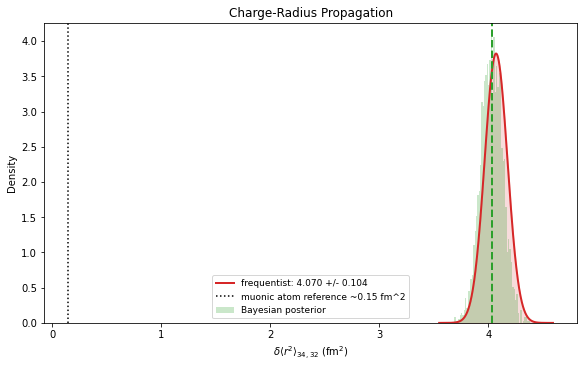

In [52]:
# Bayesian charge-radius uncertainty propagation with PyMC
# This uses the same relation:
# delta_nu = DeltaK * (1/M34 - 1/M32) + DeltaF * delta<r^2>
#
# If theory uncertainties are left at zero, DeltaK and DeltaF are fixed constants.

import matplotlib.pyplot as plt

# Sampling defaults are intentionally moderate because this Windows conda
# environment does not currently have a g++ compiler for Aesara.
bayes_draws = 1500
bayes_tune = 1000
bayes_chains = 2
bayes_cores = 1

try:
    import pymc as pm
    import arviz as az

    with pm.Model() as charge_radius_bayes_model:
        if DeltaK_total_unc_GHz_u > 0:
            dK_total_pm = pm.Normal("DeltaK_total_GHz_u", mu=dK_tot, sigma=DeltaK_total_unc_GHz_u)
        else:
            dK_total_pm = dK_tot

        if DeltaF_F0_unc_GHz_fm2 > 0:
            dF_pm = pm.Normal("DeltaF_GHz_fm2", mu=dF, sigma=DeltaF_F0_unc_GHz_fm2)
        else:
            dF_pm = dF

        delta_r2_pm = pm.Normal("delta_r2_34_32_fm2", mu=0.15, sigma=1.0)
        delta_nu_model_GHz = dK_total_pm * mu_34_32 + dF_pm * delta_r2_pm

        pm.Normal(
            "delta_nu_exp_GHz",
            mu=delta_nu_model_GHz,
            sigma=delta_nu_exp_sem_GHz,
            observed=delta_nu_exp_34_32_GHz,
        )

        charge_radius_trace = pm.sample(
            draws=bayes_draws,
            tune=bayes_tune,
            chains=bayes_chains,
            cores=bayes_cores,
            target_accept=0.95,
            random_seed=20260605,
            progressbar=False,
        )

    charge_radius_bayes_summary = az.summary(
        charge_radius_trace,
        var_names=["delta_r2_34_32_fm2"],
        hdi_prob=0.6827,
    )
    delta_r2_bayes_mean = float(charge_radius_bayes_summary.loc["delta_r2_34_32_fm2", "mean"])
    delta_r2_bayes_sd = float(charge_radius_bayes_summary.loc["delta_r2_34_32_fm2", "sd"])
    delta_r2_34_32_bayes_u = ufloat(delta_r2_bayes_mean, delta_r2_bayes_sd)

    print("Charge-radius uncertainty summary")
    print(f"Frequentist ufloat: {delta_r2_34_32_u} fm^2")
    print(f"  mean = {delta_r2_34_32_u.n:.4f} fm^2")
    print(f"  std  = {delta_r2_34_32_u.s:.4f} fm^2")
    print()
    print(f"Bayesian posterior: {delta_r2_34_32_bayes_u} fm^2")
    print(f"  mean = {delta_r2_34_32_bayes_u.n:.4f} fm^2")
    print(f"  sd   = {delta_r2_34_32_bayes_u.s:.4f} fm^2")
    display(charge_radius_bayes_summary)

    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    freq_mean = delta_r2_34_32_u.n
    freq_sd = delta_r2_34_32_u.s
    grid = np.linspace(freq_mean - 5 * freq_sd, freq_mean + 5 * freq_sd, 600)
    freq_pdf = np.exp(-0.5 * ((grid - freq_mean) / freq_sd) ** 2)
    freq_pdf /= np.trapz(freq_pdf, grid)
    ax.plot(grid, freq_pdf, color="C3", lw=2, label=f"frequentist: {freq_mean:.3f} +/- {freq_sd:.3f}")
    ax.fill_between(grid, 0, freq_pdf, color="C3", alpha=0.16)

    r2_samples = charge_radius_trace.posterior["delta_r2_34_32_fm2"].values.ravel()
    ax.hist(r2_samples, bins=60, density=True, histtype="stepfilled", alpha=0.25, color="C2", label="Bayesian posterior")
    ax.axvline(delta_r2_34_32_bayes_u.n, color="C2", lw=2, ls="--")
    ax.axvline(0.15, color="k", lw=1.5, ls=":", label="muonic atom reference ~0.15 fm^2")
    ax.set_xlabel(r"$\delta\langle r^2\rangle_{34,32}$ (fm$^2$)")
    ax.set_ylabel("Density")
    ax.set_title("Charge-Radius Propagation")
    ax.legend(fontsize=9)
    plt.show()

except ModuleNotFoundError as exc:
    charge_radius_bayes_model = None
    charge_radius_trace = None
    charge_radius_bayes_summary = None
    delta_r2_34_32_bayes_u = None
    print("PyMC Bayesian charge-radius model was not run.")
    print(f"Missing package: {exc.name}. Install pymc and arviz in this notebook environment to enable it.")


In [53]:
# Cell 10: explicitly compare sign conventions
# This is the sanity-check cell for "should the shift be positive or negative?"

mu_32_34 = mass_factor(M34_u, M32_u, convention="A'-A")

print("34 - 32 convention:")
print(f"  mu              = {mu_34_32:+.12f}")
print(f"  mass shift      = {dK_tot * mu_34_32:+.6f} GHz")
print()

print("32 - 34 convention:")
print(f"  mu              = {mu_32_34:+.12f}")
print(f"  mass shift      = {dK_tot * mu_32_34:+.6f} GHz")


34 - 32 convention:
  mu              = -0.001837710526
  mass shift      = +0.602521 GHz

32 - 34 convention:
  mu              = +0.001837710526
  mass shift      = -0.602521 GHz


In [54]:
# Cell 11: compact summary dictionary for later use

summary = {
    "lower_level_no": int(lower["No"]),
    "upper_level_no": int(upper["No"]),
    "transition_cm-1": float(upper["Energy_cm1"] - lower["Energy_cm1"]),
    "mu_34_32_u-1": float(mu_34_32),
    "DeltaK_NMS_GHz_u": float(dK_nms),
    "DeltaK_SMS_GHz_u": float(dK_sms),
    "DeltaK_total_GHz_u": float(dK_tot),
    "DeltaK_total_unc_GHz_u": float(DeltaK_total_unc_GHz_u),
    "DeltaF_F0_GHz_fm2": float(dF),
    "DeltaF_F0_unc_GHz_fm2": float(DeltaF_F0_unc_GHz_fm2),
    "delta_nu_exp_34_32_GHz": float(delta_nu_exp_34_32_GHz_u.n),
    "delta_nu_exp_sem_GHz": float(delta_nu_exp_34_32_GHz_u.s),
    "delta_nu_MS_34_32_GHz": float(delta_nu_ms_u.n),
    "delta_nu_MS_34_32_unc_GHz": float(delta_nu_ms_u.s),
    "delta_nu_FS_34_32_GHz": float((delta_nu_exp_34_32_GHz_u - delta_nu_ms_u).n),
    "delta_nu_FS_34_32_unc_GHz": float((delta_nu_exp_34_32_GHz_u - delta_nu_ms_u).s),
    "delta_r2_34_32_fm2": float(delta_r2_34_32_u.n),
    "delta_r2_sem_fm2": float(delta_r2_34_32_u.s),
    "delta_r2_bayes_fm2": None if globals().get("delta_r2_34_32_bayes_u") is None else float(delta_r2_34_32_bayes_u.n),
    "delta_r2_bayes_sd_fm2": None if globals().get("delta_r2_34_32_bayes_u") is None else float(delta_r2_34_32_bayes_u.s),
}

summary


{'lower_level_no': 6,
 'upper_level_no': 59,
 'transition_cm-1': 25462.539999999994,
 'mu_34_32_u-1': -0.0018377105255714017,
 'DeltaK_NMS_GHz_u': -336.93900000001304,
 'DeltaK_SMS_GHz_u': 9.074099999997998,
 'DeltaK_total_GHz_u': -327.86490000001504,
 'DeltaK_total_unc_GHz_u': 0.0,
 'DeltaF_F0_GHz_fm2': -0.047907799999990175,
 'DeltaF_F0_unc_GHz_fm2': 0.0,
 'delta_nu_exp_34_32_GHz': 0.4075455675767417,
 'delta_nu_exp_sem_GHz': 0.004998715616855105,
 'delta_nu_MS_34_32_GHz': 0.6025207776954427,
 'delta_nu_MS_34_32_unc_GHz': 0.0,
 'delta_nu_FS_34_32_GHz': -0.19497521011870095,
 'delta_nu_FS_34_32_unc_GHz': 0.004998715616855105,
 'delta_r2_34_32_fm2': 4.069800953471897,
 'delta_r2_sem_fm2': 0.10434032906658477,
 'delta_r2_bayes_fm2': 4.03,
 'delta_r2_bayes_sd_fm2': 0.101}

In [16]:
# Cell 12: interpretation notes

print(
    "Interpretation:\n"
    "- If delta nu_MS is positive for 34S-32S, then a positive measured shift can still be fine.\n"
    "- The field shift compensates it if Delta F < 0 and delta<r^2> > 0.\n"
    "- The red flag is not necessarily the sign, but whether the extracted delta<r^2> is physically reasonable.\n"
    "- If delta<r^2> comes out implausibly large, re-check:\n"
    "  1. transition assignment,\n"
    "  2. sign convention for isotope shift,\n"
    "  3. sign convention for K and F in the theorist table,\n"
    "  4. whether the table values are already level values or transition values intended for a different convention."
)


Interpretation:
- If delta nu_MS is positive for 34S-32S, then a positive measured shift can still be fine.
- The field shift compensates it if Delta F < 0 and delta<r^2> > 0.
- The red flag is not necessarily the sign, but whether the extracted delta<r^2> is physically reasonable.
- If delta<r^2> comes out implausibly large, re-check:
  1. transition assignment,
  2. sign convention for isotope shift,
  3. sign convention for K and F in the theorist table,
  4. whether the table values are already level values or transition values intended for a different convention.
